# O*NET Career Knowledge Base Scraper

Mengambil data dari O*NET menggunakan **endpoint CSV resmi** per section.

Data yang diambil per occupation:
- Essential Skills
- Knowledge
- Work Styles
- Career Interest Types
- Specific Interest Areas
- Abilities
- Technology Skills (Hot Tech dari job postings)

### Changelog (fixed version)
- **[FIX] Cell 6**: `GENERIC_SKILLS` sekarang pakai `snake_case` agar konsisten dengan field `normalized`
- **[FIX] Cell 6**: Occupation dengan skill kosong setelah filter tidak lagi menghasilkan nilai 0.00 — diagonal selalu 1.0
- **[FIX] Cell 6**: `clustermap` title diset via `g.fig.suptitle()` (bukan `plt.title()` yang tidak berefek)
- **[FIX] Cell 6**: Tambah validasi eksplisit diagonal = 1.0 sebelum plot
- **[IMPROVE] Cell 3**: Warning lebih informatif jika occupation tidak ditemukan di CSV
- **[IMPROVE] Cell 6**: Print ringkasan jumlah skill per occupation sebelum hitung Jaccard


In [ ]:
!pip install pandas requests seaborn matplotlib

In [11]:
import requests
import csv
import io
import json
import time
import pandas as pd

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,*/*",
    "Accept-Language": "en-US,en;q=0.9",
}

SECTION_CONFIG = {
    "tasks": {
        # Tasks punya dua kemungkinan URL tergantung occupation:
        #   prefix "tk" → ada kolom Importance (majority of occupations)
        #   prefix "ta" → tidak ada kolom Importance (e.g. Data Scientists 15-2051.00)
        # Kode akan coba "tk" dulu, kalau 404 fallback ke "ta"
        "prefix": "tk",
        "prefix_fallback": "ta",
        "filename": "Tasks",
        "sort": "IM",
        "col_name": "Task",
        "col_score": "Importance",
        "url_type": "tasks",   # tipe khusus untuk handle fallback
    },
    "work_activities": {
        "prefix": "wa",
        "filename": "Work_Activities",
        "sort": "IM",
        "col_name": "Work Activity",
        "col_score": "Importance",
        "url_type": "table",
    },
    "detailed_work_activities": {
        "prefix": "dw",
        "filename": "Detailed_Work_Activities",
        "sort": None,
        "col_name": "Detailed Work Activity",
        "col_score": None,
        "url_type": "table",
    },
    "work_context": {
        "prefix": "cx",
        "filename": "Work_Context",
        "sort": "CX",
        "col_name": "Work Context",
        "col_score": "Category Value",
        "url_type": "table",
    },
    "essential_skills": {
        "prefix": "sb",
        "filename": "Essential_Skills",
        "sort": "IM",
        "col_name": "Essential Skill",
        "col_score": "Importance",
        "url_type": "table",
    },
    "knowledge": {
        "prefix": "kn",
        "filename": "Knowledge",
        "sort": "IM",
        "col_name": "Knowledge",
        "col_score": "Importance",
        "url_type": "table",
    },
    "education": {
        "prefix": "ed",
        "filename": "Education_Training_Experience",
        "sort": "IM",
        "col_name": "Education, Training, Experience",
        "col_score": "Importance",
        "url_type": "table",
    },
    "abilities": {
        "prefix": "ab",
        "filename": "Abilities",
        "sort": "IM",
        "col_name": "Ability",
        "col_score": "Importance",
        "url_type": "table",
    },
    "career_interest_types": {
        "prefix": "in",
        "filename": "Career_Interest_Types",
        "sort": "OI",
        "col_name": "Career Interest Type",
        "col_score": "Occupational Interest",
        "url_type": "table",
    },
    "specific_interest_areas": {
        "prefix": "bi",
        "filename": "Specific_Interest_Areas",
        "sort": "OI",
        "col_name": "Specific Interest Area",
        "col_score": "Occupational Interest",
        "url_type": "table",
    },
    "work_styles": {
        "prefix": "ws",
        "filename": "Work_Styles",
        "sort": "IM",
        "col_name": "Work Style",
        "col_score": "Impact",
        "url_type": "table",
    },
    "technology_skills": {
        "prefix": None,
        "filename": "Hot_Technology",
        "sort": None,
        "col_name": "Technology Skill",
        "col_score": "Percentage",
        "url_type": "hot_tech",
    },
}


def build_url(code, prefix, filename, sort):
    code_dash = code.replace(".", "-")
    base = f"https://www.onetonline.org/link/table/details/{prefix}/{code}/{filename}_{code_dash}.csv?fmt=csv"
    if sort:
        base += f"&s={sort}&t=-10"
    return base


def fetch_csv(url, col_name, col_score, section_key):
    """Download dan parse satu CSV. Return (items, success)."""
    try:
        response = requests.get(url, headers=HEADERS, timeout=15)
        response.raise_for_status()
    except requests.HTTPError:
        return [], False
    except Exception as e:
        print(f"  [WARNING] {section_key}: {e}")
        return [], False

    items = []
    reader = csv.DictReader(io.StringIO(response.text))

    for row in reader:
        name = row.get(col_name, "").strip()
        if not name:
            continue

        score = None
        if col_score and col_score in row:
            raw = row[col_score].strip()
            if raw and raw.lower() != "n/a":
                try:
                    score = int(float(raw))
                except ValueError:
                    score = None

        if section_key == "technology_skills":
            in_demand_raw = row.get("In Demand", "").strip().lower()
            items.append({
                "name": name,
                "percentage_in_job_postings": score,
                "in_demand": in_demand_raw == "yes"
            })
        else:
            items.append({
                "name": name,
                "importance": score
            })

    return items, True


def fetch_csv_section(code, section_key):
    config = SECTION_CONFIG[section_key]
    col_name = config["col_name"]
    col_score = config["col_score"]

    # Hot tech pakai endpoint berbeda
    if config["url_type"] == "hot_tech":
        code_dash = code.replace(".", "-")
        url = f"https://www.onetonline.org/link/hot_tech/{code}/{config['filename']}_{code_dash}.csv?fmt=csv"
        items, _ = fetch_csv(url, col_name, col_score, section_key)
        return items

    # Tasks: coba prefix utama (tk) dulu, fallback ke prefix alternatif (ta)
    if config["url_type"] == "tasks":
        url_tk = build_url(code, config["prefix"], config["filename"], config["sort"])
        items, ok = fetch_csv(url_tk, col_name, col_score, section_key)
        if ok and items:
            return items

        # Fallback ke "ta" tanpa Importance
        url_ta = build_url(code, config["prefix_fallback"], config["filename"], None)
        items, ok = fetch_csv(url_ta, "Task", None, section_key)
        if ok:
            return items

        print(f"  [WARNING] {section_key}: kedua URL gagal untuk {code}")
        return []

    # Section biasa
    url = build_url(code, config["prefix"], config["filename"], config["sort"])
    items, ok = fetch_csv(url, col_name, col_score, section_key)
    if not ok:
        print(f"  [WARNING] {section_key}: gagal untuk {code}")
    return items


def scrape_onet(code):
    result = {}
    for section_key in SECTION_CONFIG:
        result[section_key] = fetch_csv_section(code, section_key)
    return result


print("Fungsi scraper siap!")

Fungsi scraper siap!


In [ ]:


# =====================================
# LOAD CSV DAFTAR OCCUPATION
# =====================================

csv_path = "/content/All_Occupations.csv"
df = pd.read_csv(csv_path)

# =====================================
# TARGET OCCUPATIONS
# =====================================

target_jobs = [
    "Data Scientists",
    "Business Intelligence Analysts",
    "Software Developers",
    "Actuaries",
    "Lawyers",
    "Information Security Analysts",
    "Machine Learning Engineers",
    "Computer Systems Analysts",
    "Database Administrators and Architects",
    "Management Analysts",
    "Project Management Specialists",
    "Market Research Analysts and Marketing Specialists",
    "Financial Managers",
    "Graphic Designers",
    "Technical Writers",
    "Producers and Directors",
    "Registered Nurses",
    "Clinical and Counseling Psychologists",
    "Industrial Engineers",
    "Civil Engineers",
]

# =====================================
# CARI OCCUPATION CODE DARI CSV
# =====================================

occupation_links = {}
not_found = []

for job in target_jobs:
    result = df[df["Occupation"].str.contains(job, case=False, na=False)]
    if len(result) > 0:
        row = result.iloc[0]
        code = row["Code"]
        occupation_links[job] = {
            "code": code,
            "url": f"https://www.onetonline.org/link/summary/{code}"
        }
        print(f"Ditemukan: {job} -> {code}")
    else:
        not_found.append(job)
        print(f"[TIDAK DITEMUKAN] {job}")

# [IMPROVE] Warning lebih informatif kalau ada yang tidak ditemukan
if not_found:
    print(f"\n[PERHATIAN] {len(not_found)} occupation tidak ditemukan:")
    for j in not_found:
        print(f"  - {j}")
    print("Occupation ini TIDAK akan di-scrape.")
    print("Dampak: di heatmap Jaccard nanti, mereka akan muncul dengan SEMUA nilai 0.00 (termasuk diagonal).")
    print("Solusi: cek ejaan vs kolom 'Occupation' di All_Occupations.csv, atau tambah code-nya manual di occupation_links.")

print(f"\nTotal ditemukan: {len(occupation_links)} dari {len(target_jobs)} target.")

# =====================================
# SCRAPE SEMUA OCCUPATION
# =====================================

all_data = {}

for job, info in occupation_links.items():
    print(f"\nScraping: {job} ({info['code']})")
    scraped = scrape_onet(info["code"])

    for section, items in scraped.items():
        print(f"  {section}: {len(items)} item(s)")

    all_data[job] = {
        "code": info["code"],
        "url": info["url"],
        "data": scraped
    }

    time.sleep(1.5)

# =====================================
# SIMPAN JSON
# =====================================

output_path = "career_knowledge_base.json"

with open(output_path, "w") as f:
    json.dump(all_data, f, indent=4)

print(f"\nDONE! Disimpan ke {output_path}")
print(f"Total occupation berhasil di-scrape: {len(all_data)}")


In [13]:
import json
from collections import defaultdict

# ============================================================
# STEP 1 — LOAD career_knowledge_base.json
# ============================================================

with open("career_knowledge_base.json", "r") as f:
    raw_data = json.load(f)

# ============================================================
# STEP 2 — KONFIGURASI FILTER
# Sesuaikan threshold ini sesuai kebutuhan
# ============================================================

IMPORTANCE_THRESHOLD = 40   # hapus item dengan importance < nilai ini
PERCENTAGE_THRESHOLD = 10   # khusus technology_skills, hapus jika % job postings < ini

# Section yang DIPAKAI untuk reasoning (sesuai saran mentor)
ACTIVE_SECTIONS = [
    "essential_skills",
    "knowledge",
    "abilities",
    "work_styles",
    "career_interest_types",
    "specific_interest_areas",
    # "tasks",                  # opsional, aktifkan kalau mau
    # "work_activities",        # opsional
    # "detailed_work_activities", # opsional
    # "work_context",           # dinonaktifkan — noise
    # "education",              # opsional
]

# ============================================================
# STEP 3 — FILTER & NORMALISASI PER OCCUPATION
# ============================================================

def normalize_name(name):
    """
    Normalisasi nama skill ke format snake_case lowercase.
    Contoh: 'Critical Thinking' → 'critical_thinking'
    """
    return name.strip().lower().replace(" ", "_").replace("-", "_").replace("/", "_")


def filter_section(items, section_key):
    """
    Filter items berdasarkan importance threshold.
    Technology skills pakai percentage_in_job_postings.
    Items tanpa importance (None) tetap dimasukkan — tidak bisa disaring.
    """
    filtered = []
    for item in items:
        if section_key == "technology_skills":
            pct = item.get("percentage_in_job_postings")
            if pct is not None and pct < PERCENTAGE_THRESHOLD:
                continue
        else:
            imp = item.get("importance")
            if imp is not None and imp < IMPORTANCE_THRESHOLD:
                continue
        filtered.append(item)
    return filtered


career_profiles = {}

for occupation, occ_data in raw_data.items():
    profile = {
        "code": occ_data["code"],
        "url": occ_data["url"],
        "required_skills": {}
    }

    raw_sections = occ_data.get("data", {})

    for section_key in ACTIVE_SECTIONS:
        items = raw_sections.get(section_key, [])
        filtered = filter_section(items, section_key)

        profile["required_skills"][section_key] = [
            {
                "raw_name": item["name"],
                "normalized": normalize_name(item["name"]),
                "importance": item.get("importance"),
            }
            for item in filtered
        ]

    career_profiles[occupation] = profile

print("Filter selesai.")
for occ, profile in career_profiles.items():
    print(f"\n{occ}:")
    for section, items in profile["required_skills"].items():
        print(f"  {section}: {len(items)} item(s)")

# ============================================================
# STEP 4 — AUTO-GENERATE MASTER TAXONOMY TEMPLATE
# Kumpulkan semua unique normalized skill dari semua occupation
# lalu buat template JSON yang tinggal kamu isi manual:
#   - aliases (sudah prefilled dengan raw_name)
#   - category (prefilled berdasarkan section)
#   - requires (kosong, isi manual)
# ============================================================

# Mapping section → category default
SECTION_CATEGORY = {
    "essential_skills":      "cognitive_skill",
    "knowledge":             "knowledge_domain",
    "abilities":             "cognitive_ability",
    "work_styles":           "work_trait",
    "career_interest_types": "interest_type",
    "specific_interest_areas": "interest_area",
    "technology_skills":     "technical_tool",
}

# Kumpulkan semua skill: normalized → {aliases, categories}
all_skills = defaultdict(lambda: {"aliases": set(), "categories": set()})

for occupation, profile in career_profiles.items():
    for section_key, items in profile["required_skills"].items():
        category = SECTION_CATEGORY.get(section_key, "general")
        for item in items:
            key = item["normalized"]
            all_skills[key]["aliases"].add(item["raw_name"])
            all_skills[key]["categories"].add(category)

# Build taxonomy template
taxonomy_template = {}

for normalized_key, meta in sorted(all_skills.items()):
    # Kalau satu skill muncul di beberapa section, ambil category paling spesifik
    # (priority: technical_tool > knowledge_domain > cognitive_skill > lainnya)
    priority = ["technical_tool", "knowledge_domain", "cognitive_skill",
                "cognitive_ability", "work_trait", "interest_type",
                "interest_area", "general"]
    chosen_category = "general"
    for p in priority:
        if p in meta["categories"]:
            chosen_category = p
            break

    taxonomy_template[normalized_key] = {
        "aliases": sorted(list(meta["aliases"])),   # prefilled, tinggal cek
        "category": chosen_category,                 # prefilled, bisa diubah
        "requires": []                               # MANUAL: isi prerequisite
    }

print(f"\nTotal unique skills di taxonomy: {len(taxonomy_template)}")

# ============================================================
# STEP 5 — SIMPAN SEMUA OUTPUT
# ============================================================

# career_profiles_filtered.json — data per occupation yang sudah difilter
with open("career_profiles_filtered.json", "w") as f:
    json.dump(career_profiles, f, indent=4)

# master_skill_taxonomy_template.json — template taxonomy, EDIT MANUAL bagian requires
with open("master_skill_taxonomy_template.json", "w") as f:
    json.dump(taxonomy_template, f, indent=4)

print("\nFile tersimpan:")
print("  career_profiles_filtered.json       ← data per occupation, sudah filtered")
print("  master_skill_taxonomy_template.json ← taxonomy template, edit bagian 'requires'")

Filter selesai.

Data Scientists:
  essential_skills: 0 item(s)
  knowledge: 0 item(s)
  abilities: 0 item(s)
  work_styles: 12 item(s)
  career_interest_types: 2 item(s)
  specific_interest_areas: 2 item(s)

Business Intelligence Analysts:
  essential_skills: 9 item(s)
  knowledge: 7 item(s)
  abilities: 20 item(s)
  work_styles: 14 item(s)
  career_interest_types: 3 item(s)
  specific_interest_areas: 6 item(s)

Software Developers:
  essential_skills: 9 item(s)
  knowledge: 8 item(s)
  abilities: 18 item(s)
  work_styles: 14 item(s)
  career_interest_types: 3 item(s)
  specific_interest_areas: 3 item(s)

Actuaries:
  essential_skills: 9 item(s)
  knowledge: 6 item(s)
  abilities: 21 item(s)
  work_styles: 10 item(s)
  career_interest_types: 2 item(s)
  specific_interest_areas: 3 item(s)

Lawyers:
  essential_skills: 8 item(s)
  knowledge: 8 item(s)
  abilities: 22 item(s)
  work_styles: 16 item(s)
  career_interest_types: 4 item(s)
  specific_interest_areas: 4 item(s)

Information Se

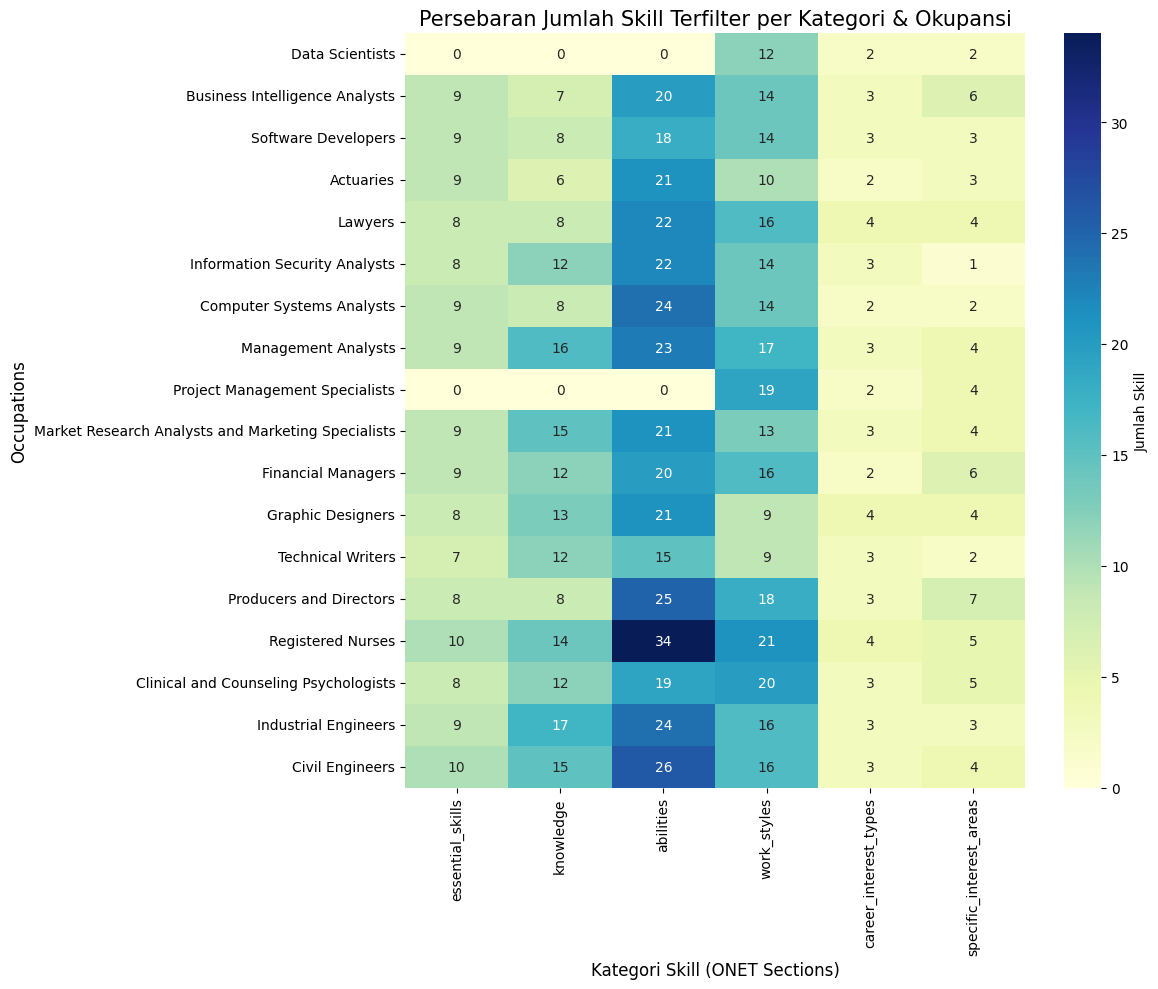

Ringkasan Statistik Jumlah Skill:


,essential_skills,knowledge,abilities,work_styles,career_interest_types,specific_interest_areas
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,7.722222,10.166667,19.722222,14.888889,2.888889,3.833333
std,2.906495,4.949747,8.180361,3.496029,0.676400,1.581139
min,0.000000,0.000000,0.000000,9.000000,2.000000,1.000000
25%,8.000000,8.000000,19.250000,13.250000,2.250000,3.000000
50%,9.000000,12.000000,21.000000,15.000000,3.000000,4.000000
75%,9.000000,13.750000,23.750000,16.750000,3.000000,4.750000
max,10.000000,17.000000,34.000000,21.000000,4.000000,7.000000


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# 1. Load data filtered
with open('career_profiles_filtered.json', 'r') as f:
    profiles = json.load(f)

# 2. Siapkan data untuk DataFrame persebaran
data_dist = []
for occupation, details in profiles.items():
    counts = {'Occupation': occupation}
    for section, items in details['required_skills'].items():
        counts[section] = len(items)
    data_dist.append(counts)

df_dist = pd.DataFrame(data_dist).set_index('Occupation')

# 3. Visualisasi Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_dist, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Jumlah Skill'})
plt.title('Persebaran Jumlah Skill Terfilter per Kategori & Okupansi', fontsize=15)
plt.xlabel('Kategori Skill (ONET Sections)', fontsize=12)
plt.ylabel('Occupations', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Tampilkan Tabel Statistik Sederhana
print("Ringkasan Statistik Jumlah Skill:")
display(df_dist.describe())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

# ============================================================
# 1. Load data filtered
# ============================================================

with open('career_profiles_filtered.json', 'r') as f:
    profiles = json.load(f)

# ============================================================
# 2. Ekstrak set skill per occupation
#    Sections yang dipakai: hard skills saja
# ============================================================

HARD_SKILL_SECTIONS = [
    'essential_skills',
    'knowledge',
    'abilities'
]

# [FIX] GENERIC_SKILLS harus pakai snake_case
# karena item['normalized'] sudah di-convert ke snake_case oleh normalize_name()
# Bug lama: 'critical thinking' != 'critical_thinking' → filter tidak pernah jalan
GENERIC_SKILLS = {
    'communication',
    'critical_thinking',
    'active_listening',
    'coordination',
    'monitoring',
    'speaking',
    'writing',
    'judgment_and_decision_making',
    'problem_solving',
    'social_perceptiveness'
}

occ_skills = {}

for occ, details in profiles.items():
    skill_weights = {}

    for section, items in details['required_skills'].items():
        if section not in HARD_SKILL_SECTIONS:
            continue

        for item in items:
            skill = item['normalized']  # sudah snake_case lowercase, tidak perlu .lower() lagi

            if skill in GENERIC_SKILLS:
                continue

            importance = item.get('importance') or 50  # fallback 50 jika None

            if skill not in skill_weights:
                skill_weights[skill] = importance
            else:
                skill_weights[skill] = max(skill_weights[skill], importance)

    occ_skills[occ] = skill_weights

# ============================================================
# 3. Ringkasan & validasi sebelum hitung Jaccard
# ============================================================

print("=== RINGKASAN JUMLAH SKILL PER OCCUPATION (setelah filter generic) ===")
empty_occs = []
for occ, skills in occ_skills.items():
    status = "OK" if skills else "*** KOSONG — akan menyebabkan baris 0.00 di heatmap! ***"
    print(f"  {occ}: {len(skills)} skill(s)  {status}")
    if not skills:
        empty_occs.append(occ)

if empty_occs:
    print(f"\n[PERINGATAN] {len(empty_occs)} occupation dengan skill kosong: {empty_occs}")
    print("Kemungkinan penyebab:")
    print("  1. Occupation tidak ditemukan di All_Occupations.csv (tidak ter-scrape)")
    print("  2. IMPORTANCE_THRESHOLD terlalu tinggi — semua skill tersaring habis")
    print("  3. Data O*NET untuk occupation ini memang minimal")
    print("\nSolusi:")
    print("  - Cek Cell 3 output: apakah occupation ini berhasil di-scrape?")
    print("  - Turunkan IMPORTANCE_THRESHOLD di Cell 4 (coba 30 atau 20)")
    print("  - Atau hapus occupation bermasalah dari analisis ini:")
    print(f"    occ_skills = {{k: v for k, v in occ_skills.items() if v}}")

# ============================================================
# 4. Hitung Jaccard Similarity (Weighted)
#    Jaccard = sum(min(w_i, w_j)) / sum(max(w_i, w_j))
#    [FIX] Diagonal selalu 1.0 (self-similarity)
#    [FIX] Occupation kosong tidak ikut dihitung (skip, bukan set 0)
# ============================================================

# Opsional: skip occupation yang kosong agar tidak merusak visualisasi
# Uncomment baris di bawah ini jika ingin exclude occupation bermasalah:
# occ_skills = {k: v for k, v in occ_skills.items() if v}

occupations = list(occ_skills.keys())
n = len(occupations)
corr_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):

        # [FIX] Diagonal selalu 1.0 — occupation sama dengan dirinya sendiri = identik
        if i == j:
            corr_matrix[i, j] = 1.0
            continue

        set_i = occ_skills[occupations[i]]
        set_j = occ_skills[occupations[j]]

        # Jika salah satu kosong, similarity = 0 (tidak bisa dibandingkan)
        if not set_i or not set_j:
            corr_matrix[i, j] = 0.0
            continue

        all_skills_union = set(set_i.keys()).union(set_j.keys())

        numerator = 0
        denominator = 0

        for skill in all_skills_union:
            weight_i = set_i.get(skill, 0)
            weight_j = set_j.get(skill, 0)
            numerator += min(weight_i, weight_j)
            denominator += max(weight_i, weight_j)

        corr_matrix[i, j] = numerator / denominator if denominator != 0 else 0.0

df_corr = pd.DataFrame(corr_matrix, index=occupations, columns=occupations)

# Verifikasi diagonal
diag_vals = np.diag(corr_matrix)
print(f"\nVerifikasi diagonal (semua harus 1.0): min={diag_vals.min():.2f}, max={diag_vals.max():.2f}")

# ============================================================
# 5. Visualisasi Clustermap
#    [FIX] Title diset via g.fig.suptitle() — plt.title() tidak bekerja pada clustermap
# ============================================================

g = sns.clustermap(
    df_corr,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    figsize=(16, 14),
    vmin=0,
    vmax=1,
    annot_kws={"size": 8}
)

# [FIX] Cara yang benar untuk memberi judul pada clustermap
g.fig.suptitle(
    'Korelasi Antar Okupansi Berdasarkan Kesamaan Skill (Jaccard Similarity)',
    fontsize=13,
    y=1.01
)

# Rotasi label agar lebih terbaca
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# 6. Contoh spesifik: shared skills antara dua occupation
# ============================================================

occ_a = 'Civil Engineers'
occ_b = 'Industrial Engineers'

if occ_a in occ_skills and occ_b in occ_skills:
    shared = set(occ_skills[occ_a].keys()).intersection(set(occ_skills[occ_b].keys()))
    print(f"\nSkill yang sama antara '{occ_a}' & '{occ_b}' ({len(shared)} skill):")
    print(sorted(list(shared)))
else:
    print(f"\n[INFO] Salah satu dari '{occ_a}' atau '{occ_b}' tidak ada di data — cek Cell 3.")
